# gmem4 Memory Snapshot Statistics
Per-session analysis of graph structure, edge distributions, and node attributes.

In [1]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
GMEM4_DIR   = "/NAS/wonjun/exp_implexconv_no_response/gmem5"
MODEL       = "Qwen3-1.7B"
SUBSET      = "opposed"         # 'opposed' or 'supportive'
CONFIG_N    = 0

START_SESSION = 0
END_SESSION   = 15             # inclusive
# ────────────────────────────────────────────────────────────────────────────

In [2]:
import json
import os
from collections import defaultdict
from itertools import combinations_with_replacement
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from IPython.display import display

In [3]:
# ── Helpers ──────────────────────────────────────────────────────────────────

OUTPUT_BASE = Path(GMEM4_DIR) / f"config_{CONFIG_N}_outputs_{MODEL}_{SUBSET}"


def _build_session_map(output_base: Path) -> dict[int, Path]:
    mapping = {}
    for range_dir in sorted(output_base.iterdir()):
        snapshots_dir = range_dir / "memory_snapshots"
        if not snapshots_dir.exists():
            continue
        for sess_dir in snapshots_dir.iterdir():
            if sess_dir.is_dir() and sess_dir.name.startswith("session_"):
                sid = int(sess_dir.name.split("_")[1])
                mapping[sid] = sess_dir
    return mapping


SESSION_MAP = _build_session_map(OUTPUT_BASE)
print(f"Available sessions: {min(SESSION_MAP)} – {max(SESSION_MAP)}  (total {len(SESSION_MAP)})")


def load_graph(session_id: int) -> dict | None:
    path = SESSION_MAP.get(session_id)
    if path is None:
        return None
    graph_path = path / "graph" / "graph.json"
    if not graph_path.exists():
        return None
    with open(graph_path) as f:
        return json.load(f)


EDGE_SUBTYPES = ["SUPPORT", "CONTRADICT", "IRRELEVANT", "SHIFT_TO"]
SCOPE_VALS    = ["BROAD", "NARROW"]
IMPACT_VALS   = ["HIGH", "LOW"]
NODE_TYPES    = ["c", "m", "s", "t"]


def _pair_key(t1: str, t2: str) -> str:
    return "-".join(sorted([t1, t2]))


def compute_stats(graph: dict) -> dict:
    nodes    = graph["nodes"]
    evid_out = graph.get("evid_out", {})

    # 1. Node counts
    node_counts = defaultdict(int)
    for nid, nd in nodes.items():
        node_counts[nd["node_type"]] += 1

    # 2. Evidence edges by pair type
    edge_counts = defaultdict(lambda: defaultdict(int))
    for src_id, targets in evid_out.items():
        src_type = nodes[src_id]["node_type"]
        for tgt_id, subtype in targets.items():
            tgt_type = nodes[tgt_id]["node_type"]
            key = _pair_key(src_type, tgt_type)
            edge_counts[key][subtype] += 1

    # 3. Scope — m, s, t nodes
    scope_counts = defaultdict(int)
    for nd in nodes.values():
        if nd["node_type"] in ("m", "s", "t"):
            scope_counts[str(nd.get("scope"))] += 1

    # 4. current_decision_impact — s nodes only
    impact_counts = defaultdict(int)
    for nd in nodes.values():
        if nd["node_type"] == "s":
            impact_counts[str(nd.get("current_decision_impact"))] += 1

    # 5. Retrieval counts — all nodes
    retrieval_counts = [nd.get("retrieval_count", 0) for nd in nodes.values()]

    # 6. Unique content per node type
    content_sets = defaultdict(set)
    for nd in nodes.values():
        nt = nd["node_type"]
        content = nd.get("content", "")
        if content:
            content_sets[nt].add(content)
    unique_content = {nt: len(s) for nt, s in content_sets.items()}

    return {
        "node_counts":    dict(node_counts),
        "edge_counts":    {k: dict(v) for k, v in edge_counts.items()},
        "scope_counts":   dict(scope_counts),
        "impact_counts":  dict(impact_counts),
        "retrieval_counts": retrieval_counts,
        "unique_content": unique_content,
    }

Available sessions: 0 – 199  (total 200)


In [4]:
# ── Load sessions ─────────────────────────────────────────────────────────────

session_ids = list(range(START_SESSION, END_SESSION + 1))
all_stats   = {}
missing     = []

for sid in session_ids:
    g = load_graph(sid)
    if g is None:
        missing.append(sid)
    else:
        all_stats[sid] = compute_stats(g)

print(f"Loaded {len(all_stats)} sessions.")
if missing:
    print(f"Missing/skipped: {missing}")

Loaded 16 sessions.


## 1. Node Counts per Session

In [5]:
node_rows = []
for sid, s in all_stats.items():
    nc = s["node_counts"]
    node_rows.append({
        "session": sid,
        "c": nc.get("c", 0),
        "m": nc.get("m", 0),
        "s": nc.get("s", 0),
        "t": nc.get("t", 0),
        "total": sum(nc.values()),
    })

df_nodes = pd.DataFrame(node_rows).set_index("session")
display(df_nodes)

,c,m,s,t,total
session,,,,,
0,656,110,589,55,1410
1,648,110,587,55,1400
2,652,110,578,55,1395
3,642,110,565,55,1372
4,629,110,555,55,1349
5,652,110,595,55,1412
6,645,110,585,55,1395
7,660,110,596,55,1421
8,644,110,567,55,1376


## 2. Evidence Edges per Session

In [6]:
# Collect all pair keys that appear across sessions
all_pairs = sorted({pk for s in all_stats.values() for pk in s["edge_counts"]})
print("Pairs found:", all_pairs)

edge_rows = []
for sid, s in all_stats.items():
    row = {"session": sid}
    for pk in all_pairs:
        ec = s["edge_counts"].get(pk, {})
        for sub in EDGE_SUBTYPES:
            row[f"{pk}/{sub}"] = ec.get(sub, 0)
    edge_rows.append(row)

df_edges = pd.DataFrame(edge_rows).set_index("session")

for pk in all_pairs:
    cols = [f"{pk}/{sub}" for sub in EDGE_SUBTYPES]
    sub_df = df_edges[cols].copy()
    sub_df.columns = EDGE_SUBTYPES
    print(f"\n--- pair: {pk} ---")
    display(sub_df)

Pairs found: ['m-m', 'm-s', 'm-t', 's-s', 's-t', 't-t']

--- pair: m-m ---


,SUPPORT,CONTRADICT,IRRELEVANT,SHIFT_TO
session,,,,
0,82,0,27,0
1,81,0,28,0
2,88,0,21,0
3,79,0,30,0
4,72,0,37,0
5,71,0,38,0
6,82,0,27,0
7,76,0,33,0
8,73,0,36,0



--- pair: m-s ---


,SUPPORT,CONTRADICT,IRRELEVANT,SHIFT_TO
session,,,,
0,597,1,11,0
1,581,3,18,0
2,578,0,19,0
3,552,0,22,0
4,552,4,17,0
5,586,0,20,0
6,590,0,16,0
7,589,1,24,0
8,556,2,16,0



--- pair: m-t ---


...

,SUPPORT,CONTRADICT,IRRELEVANT,SHIFT_TO
session,,,,
0,1750,36,61,13
1,1709,46,52,5
2,1703,36,60,4
3,1664,38,53,5
4,1620,47,68,6
5,1729,56,62,2
6,1724,62,45,5
7,1730,53,74,10
8,1634,71,47,2



--- pair: s-t ---


,SUPPORT,CONTRADICT,IRRELEVANT,SHIFT_TO
session,,,,
0,833,11,119,0
1,727,14,224,0
2,715,17,223,0
3,739,5,196,0
4,729,13,187,0
5,739,14,214,0
6,739,16,207,0
7,744,3,224,0
8,673,4,268,0



--- pair: t-t ---


,SUPPORT,CONTRADICT,IRRELEVANT,SHIFT_TO
session,,,,
0,15,0,0,13
1,9,0,0,13
2,13,0,0,15
3,11,0,0,14
4,7,0,0,15
5,12,0,0,15
6,13,0,0,15
7,11,0,0,14
8,10,0,0,14


## 3. Scope Distribution (m, s, t nodes)

In [7]:
scope_rows = []
for sid, s in all_stats.items():
    sc = s["scope_counts"]
    scope_rows.append({
        "session": sid,
        "BROAD":  sc.get("BROAD", 0),
        "NARROW": sc.get("NARROW", 0),
        "None":   sc.get("None", 0),
    })

df_scope = pd.DataFrame(scope_rows).set_index("session")
display(df_scope)

,BROAD,NARROW,None
session,,,
0,275,479,0
1,277,475,0
2,281,462,0
3,314,416,0
4,273,447,0
5,265,495,0
6,269,481,0
7,269,492,0
8,261,471,0


## 4. current_decision_impact Distribution (s nodes)

In [8]:
impact_rows = []
for sid, s in all_stats.items():
    ic = s["impact_counts"]
    impact_rows.append({
        "session": sid,
        "HIGH":  ic.get("HIGH", 0),
        "LOW":   ic.get("LOW", 0),
        "None":  ic.get("None", 0),
    })

df_impact = pd.DataFrame(impact_rows).set_index("session")
display(df_impact)

,HIGH,LOW,None
session,,,
0,22,567,0
1,36,551,0
2,20,558,0
3,32,533,0
4,30,525,0
5,34,561,0
6,32,553,0
7,16,580,0
8,23,544,0


## 5. Unique Content per Node Type (Duplicate Rate)

In [9]:
uc_rows = []
for sid, s in all_stats.items():
    nc = s["node_counts"]
    uc = s["unique_content"]
    row = {"session": sid}
    for nt in NODE_TYPES:
        total  = nc.get(nt, 0)
        unique = uc.get(nt, 0)
        dup_rate = 1 - unique / total if total > 0 else 0.0
        row[f"{nt}_total"]    = total
        row[f"{nt}_unique"]   = unique
        row[f"{nt}_dup_rate"] = round(dup_rate, 3)
    uc_rows.append(row)

df_uc = pd.DataFrame(uc_rows).set_index("session")

# Display totals + unique + dup_rate per node type
for nt in NODE_TYPES:
    cols = [f"{nt}_total", f"{nt}_unique", f"{nt}_dup_rate"]
    print(f"\n--- node type: {nt} ---")
    display(df_uc[cols])


--- node type: c ---


,c_total,c_unique,c_dup_rate
session,,,
0,656,647,0.014
1,648,648,0.000
2,652,652,0.000
3,642,634,0.012
4,629,629,0.000
5,652,649,0.005
6,645,644,0.002
7,660,644,0.024
8,644,644,0.000



--- node type: m ---


,m_total,m_unique,m_dup_rate
session,,,
0,110,110,0.0
1,110,110,0.0
2,110,110,0.0
3,110,110,0.0
4,110,110,0.0
5,110,110,0.0
6,110,110,0.0
7,110,110,0.0
8,110,110,0.0



--- node type: s ---


,s_total,s_unique,s_dup_rate
session,,,
0,589,569,0.034
1,587,570,0.029
2,578,567,0.019
3,565,556,0.016
4,555,545,0.018
5,595,581,0.024
6,585,572,0.022
7,596,582,0.023
8,567,549,0.032



--- node type: t ---


,t_total,t_unique,t_dup_rate
session,,,
0,55,55,0.0
1,55,55,0.0
2,55,55,0.0
3,55,55,0.0
4,55,55,0.0
5,55,55,0.0
6,55,55,0.0
7,55,55,0.0
8,55,55,0.0


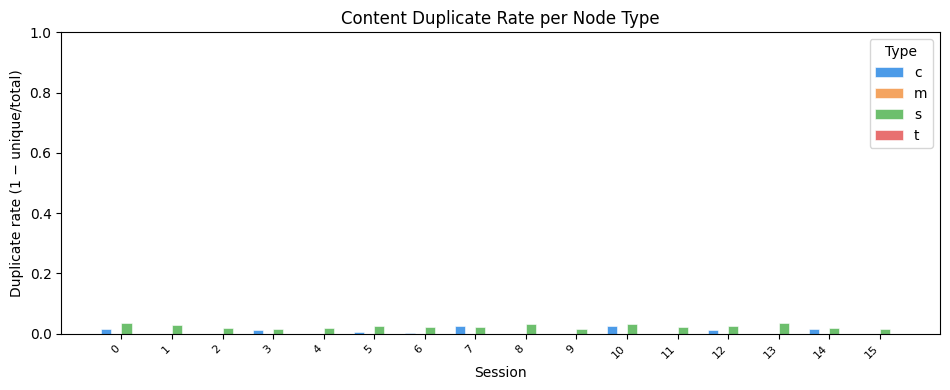

In [10]:
# ── Fig 5: Duplicate rate per node type per session ───────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(all_stats) * 0.6), 4))
x = np.arange(len(df_uc))
bar_w = 0.2
nt_colors = {"c": "#4C9BE8", "m": "#F4A460", "s": "#6DBF6D", "t": "#E87070"}
offsets = np.linspace(-(len(NODE_TYPES)-1)*bar_w/2, (len(NODE_TYPES)-1)*bar_w/2, len(NODE_TYPES))

for i, nt in enumerate(NODE_TYPES):
    vals = df_uc[f"{nt}_dup_rate"].values
    ax.bar(x + offsets[i], vals, width=bar_w, label=nt, color=nt_colors[nt],
           edgecolor="white", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(df_uc.index, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Session")
ax.set_ylabel("Duplicate rate (1 − unique/total)")
ax.set_ylim(0, 1)
ax.set_title("Content Duplicate Rate per Node Type")
ax.legend(title="Type")
plt.tight_layout()
plt.show()

In [11]:
retrieval_rows = []
for sid, s in all_stats.items():
    rc = s["retrieval_counts"]
    retrieval_rows.append({
        "session": sid,
        "mean":    np.mean(rc),
        "median":  np.median(rc),
        "max":     np.max(rc),
        "0": rc.count(0),
        "1-5":  sum(1 for x in rc if 1 <= x <= 5),
        "6-20": sum(1 for x in rc if 6 <= x <= 20),
        ">20":  sum(1 for x in rc if x > 20),
    })

df_retrieval = pd.DataFrame(retrieval_rows).set_index("session")
display(df_retrieval.round(2))

,mean,median,max,0,1-5,6-20,>20
session,,,,,,,
0,14.67,1.0,343,0,885,253,272
1,14.62,1.0,238,0,850,250,300
2,14.60,1.0,422,0,863,231,301
3,14.90,1.0,371,0,853,231,288
4,14.87,1.0,361,0,836,229,284
5,14.71,1.0,373,0,854,258,300
6,14.54,1.0,284,0,872,228,295
7,14.48,1.0,460,0,910,230,281
8,14.77,1.0,323,0,845,243,288


---
## Visualizations

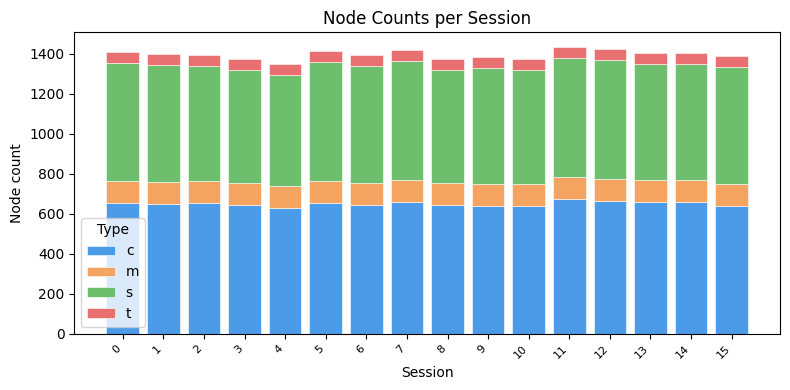

In [12]:
# ── Fig 1: Node counts per session (stacked bar) ─────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(all_stats) * 0.5), 4))
bottom = np.zeros(len(df_nodes))
colors = {"c": "#4C9BE8", "m": "#F4A460", "s": "#6DBF6D", "t": "#E87070"}
x = np.arange(len(df_nodes))
for col in ["c", "m", "s", "t"]:
    vals = df_nodes[col].values
    ax.bar(x, vals, bottom=bottom, label=col, color=colors[col], edgecolor="white", linewidth=0.4)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(df_nodes.index, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Session")
ax.set_ylabel("Node count")
ax.set_title("Node Counts per Session")
ax.legend(title="Type")
plt.tight_layout()
plt.show()

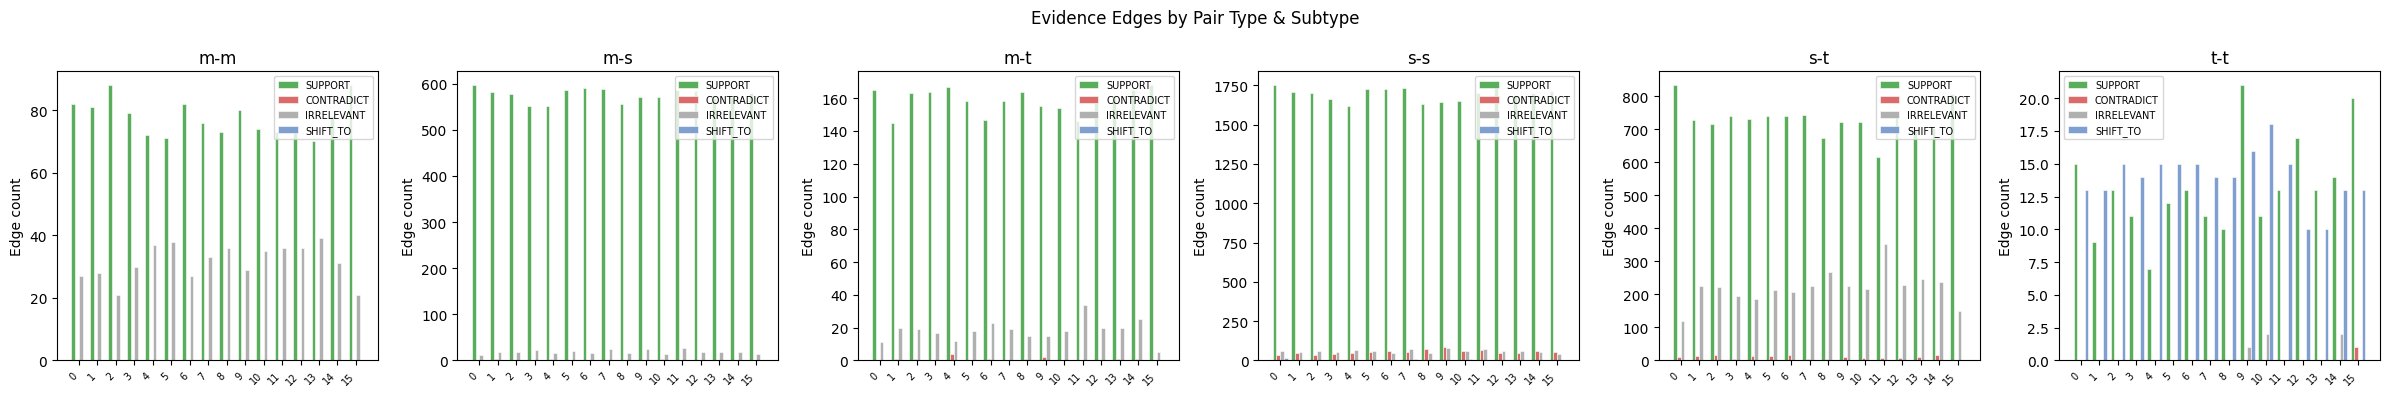

In [13]:
# ── Fig 2: Evidence edges by subtype, grouped by pair type ───────────────────
# Aggregate across sessions for readability; one sub-figure per pair type
n_pairs = len(all_pairs)
n_sessions = len(all_stats)
session_labels = list(all_stats.keys())

fig, axes = plt.subplots(1, n_pairs, figsize=(4 * n_pairs, 4), sharey=False)
if n_pairs == 1:
    axes = [axes]

sub_colors = {
    "SUPPORT":    "#5AAD5A",
    "CONTRADICT": "#D96B6B",
    "IRRELEVANT": "#B0B0B0",
    "SHIFT_TO":   "#7E9FD0",
}

x = np.arange(n_sessions)
bar_w = 0.2

for ax, pk in zip(axes, all_pairs):
    offsets = np.linspace(-(len(EDGE_SUBTYPES)-1)*bar_w/2,
                          (len(EDGE_SUBTYPES)-1)*bar_w/2,
                          len(EDGE_SUBTYPES))
    for i, sub in enumerate(EDGE_SUBTYPES):
        col = f"{pk}/{sub}"
        vals = df_edges[col].values if col in df_edges.columns else np.zeros(n_sessions)
        ax.bar(x + offsets[i], vals, width=bar_w, label=sub,
               color=sub_colors[sub], edgecolor="white", linewidth=0.4)
    ax.set_title(pk)
    ax.set_xticks(x)
    ax.set_xticklabels(session_labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Edge count")
    ax.legend(fontsize=7)

fig.suptitle("Evidence Edges by Pair Type & Subtype", fontsize=12)
plt.tight_layout()
plt.show()

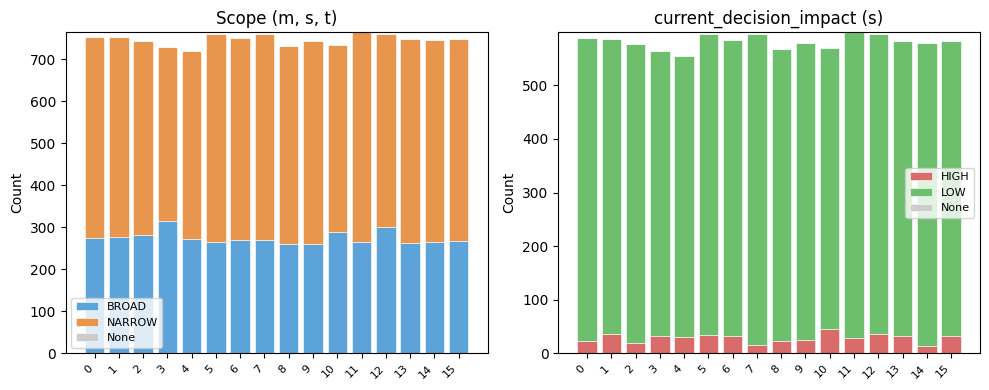

In [14]:
# ── Fig 3: Scope / Impact — stacked bar per session ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

def stacked_bar(ax, df, cols, colors_map, title):
    x = np.arange(len(df))
    bottom = np.zeros(len(df))
    for col in cols:
        if col not in df.columns:
            continue
        vals = df[col].values
        ax.bar(x, vals, bottom=bottom, label=col, color=colors_map[col],
               edgecolor="white", linewidth=0.4)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend(fontsize=8)

stacked_bar(axes[0], df_scope,
    ["BROAD", "NARROW", "None"],
    {"BROAD": "#5BA3D9", "NARROW": "#E8964D", "None": "#CCCCCC"},
    "Scope (m, s, t)")

stacked_bar(axes[1], df_impact,
    ["HIGH", "LOW", "None"],
    {"HIGH": "#D96B6B", "LOW": "#6DBF6D", "None": "#CCCCCC"},
    "current_decision_impact (s)")

plt.tight_layout()
plt.show()